## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [7]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-June-1st_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [8]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-06-01,2023,6,2023-05-28,40.659996,22.397246,0.302703,0.011088,-0.246398,-0.011088,0.249916,-0.042660,-0.231759,0.042660,0.083576,0.065710,0.068822,0.065710,2023-05-28,40.659996,22.397246,15200.0,NaN,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-05-31,40.650186,22.350102,134.134354,2023-05-25,2023-05-18,2023-05-25,2023-05-18,1.854998,3.620144
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-06-01,2023,6,2023-05-28,40.677962,22.464619,0.208054,-0.107364,-0.211306,0.107364,0.231421,-0.081907,-0.231235,0.081907,0.079186,0.056961,0.058580,0.056961,2023-05-28,40.677962,22.464619,15144.0,NaN,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-05-31,40.650186,22.450103,101.256265,2023-05-25,2023-05-18,2023-05-25,2023-05-18,0.895540,2.605121
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-06-01,2023,6,2023-05-28,40.624063,22.491569,0.267830,-0.037869,-0.292079,0.037869,0.236022,-0.060681,-0.264777,0.060681,0.054262,0.042445,0.037109,0.042445,2023-05-28,40.624063,22.491569,15279.0,NaN,40.624063,22.491569,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,2023-05-31,40.650186,22.450103,101.256265,2023-05-25,2023-05-18,2023-05-25,2023-05-18,0.895540,2.605121
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-06-01,2023,6,2023-05-28,40.624063,22.585892,0.164494,-0.114050,-0.197574,0.114050,0.141706,-0.111486,-0.172738,0.111486,0.031074,0.031043,0.027465,0.031043,2023-05-28,40.624063,22.585892,15092.0,14339.0,40.624063,22.585892,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,2023-05-31,40.650186,22.550103,104.295129,2023-05-25,2023-05-18,2023-05-25,2023-05-18,11.620570,12.976364
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-06-01,2023,6,2023-05-28,40.947456,22.060378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-28,40.947456,22.060378,15077.0,14228.0,40.947456,22.060378,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,2023-05-31,40.950187,22.050101,229.241298,2023-05-25,2023-05-18,2023-05-25,2023-05-18,18.887070,29.423067


In [9]:
#wnv_file.head()

In [10]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [11]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [12]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [13]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-06-01,2023,6,0.302703,0.011088,-0.246398,-0.011088,0.249916,-0.042660,-0.231759,0.042660,0.083576,0.065710,0.068822,0.065710,15200.0,NaN,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,134.134354,1.854998,3.620144
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-06-01,2023,6,0.208054,-0.107364,-0.211306,0.107364,0.231421,-0.081907,-0.231235,0.081907,0.079186,0.056961,0.058580,0.056961,15144.0,NaN,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,101.256265,0.895540,2.605121
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-06-01,2023,6,0.267830,-0.037869,-0.292079,0.037869,0.236022,-0.060681,-0.264777,0.060681,0.054262,0.042445,0.037109,0.042445,15279.0,NaN,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,101.256265,0.895540,2.605121
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-06-01,2023,6,0.164494,-0.114050,-0.197574,0.114050,0.141706,-0.111486,-0.172738,0.111486,0.031074,0.031043,0.027465,0.031043,15092.0,14339.0,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,104.295129,11.620570,12.976364
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-06-01,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15077.0,14228.0,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,229.241298,18.887070,29.423067


In [14]:
#wnv_file.head(5)

In [15]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [16]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [17]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [18]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [19]:
# merged

In [20]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [21]:
merged['case'].value_counts()

0    180
Name: case, dtype: int64

In [22]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [23]:
dataset = grouped.mean()

In [24]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-06-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2023.0,6.0,0.235770,-0.062049,-0.236839,0.062049,0.214766,-0.074184,-0.225127,0.074184,0.062025,0.049040,0.047994,0.049040,15178.750000,14339.000000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,110.235503,3.816662,5.451688,0.0
1,2023-06-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2023.0,6.0,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14740.600000,14144.500000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,257.681940,3.718226,48.967830,0.0
2,2023-06-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15139.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,251.891959,54.540328,73.751313,0.0
3,2023-06-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2023.0,6.0,0.505204,0.326837,-0.385542,-0.326837,0.485806,0.292957,-0.381219,-0.292957,0.053260,0.065181,0.034598,0.065181,14830.750000,14223.333333,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,106.121052,1.954789,11.972853,0.0
4,2023-06-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2023.0,6.0,0.669556,0.329771,-0.542445,-0.329771,0.658577,0.359345,-0.526910,-0.359345,0.058441,0.046232,0.051163,0.046232,14795.750000,14180.714286,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,243.895665,0.498732,18.989207,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-06-01,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2023.0,6.0,0.500126,0.156601,-0.407534,-0.156601,0.491577,0.151494,-0.401857,-0.151494,0.057268,0.049846,0.035242,0.049846,14964.800000,14182.400000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,302.647467,0.765245,4.268414,0.0
34,2023-06-01,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2023.0,6.0,0.494128,0.098056,-0.429522,-0.098056,0.461920,0.118555,-0.392807,-0.118555,0.055241,0.065680,0.040132,0.065680,14924.000000,14221.500000,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,136.935149,3.391235,9.263252,0.0
35,2023-06-01,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14921.500000,NaN,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,167.306443,4.736806,6.987233,0.0
36,2023-06-01,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2023.0,6.0,0.185661,0.097030,-0.104686,-0.097030,0.201550,0.069232,-0.151075,-0.069232,0.045375,0.047731,0.069015,0.047731,15078.666667,NaN,14257.445455,13836.255556,14236.866300,13751.761905,14546.523148,13945.631235,14648.490028,14101.385185,125.074417,8.224890,11.329436,0.0


In [25]:
dataset = dataset.astype({'case': 'int'})

In [26]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [27]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [28]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [29]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [30]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-06-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,6,0.235770,-0.062049,-0.236839,0.062049,0.214766,-0.074184,-0.225127,0.074184,0.062025,0.049040,0.047994,0.049040,15178.750000,14339.000000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,110.235503,3.816662,5.451688,0,1,22,46.44911,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
1,2023-06-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,6,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14740.600000,14144.500000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,257.681940,3.718226,48.967830,0,1,22,46.48134,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
2,2023-06-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15139.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,251.891959,54.540328,73.751313,0,1,22,46.65786,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
3,2023-06-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,6,0.505204,0.326837,-0.385542,-0.326837,0.485806,0.292957,-0.381219,-0.292957,0.053260,0.065181,0.034598,0.065181,14830.750000,14223.333333,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,106.121052,1.954789,11.972853,0,1,22,47.42581,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
4,2023-06-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,6,0.669556,0.329771,-0.542445,-0.329771,0.658577,0.359345,-0.526910,-0.359345,0.058441,0.046232,0.051163,0.046232,14795.750000,14180.714286,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,243.895665,0.498732,18.989207,0,1,22,46.91682,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-06-01,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2023,6,0.500126,0.156601,-0.407534,-0.156601,0.491577,0.151494,-0.401857,-0.151494,0.057268,0.049846,0.035242,0.049846,14964.800000,14182.400000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,302.647467,0.765245,4.268414,0,1,22,46.65417,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
34,2023-06-01,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2023,6,0.494128,0.098056,-0.429522,-0.098056,0.461920,0.118555,-0.392807,-0.118555,0.055241,0.065680,0.040132,0.065680,14924.000000,14221.500000,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,136.935149,3.391235,9.263252,0,1,22,47.47426,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
35,2023-06-01,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14921.500000,NaN,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,167.306443,4.736806,6.987233,0,1,22,46.44339,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
36,2023-06-01,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2023,6,0.185661,0.097030,-0.104686,-0.097030,0.201550,0.069232,-0.151075,-0.069232,0.045375,0.047731,0.069015,0.047731,15078.666667,NaN,14257.445455,13836.255556,14236.866300,137

<AxesSubplot:>

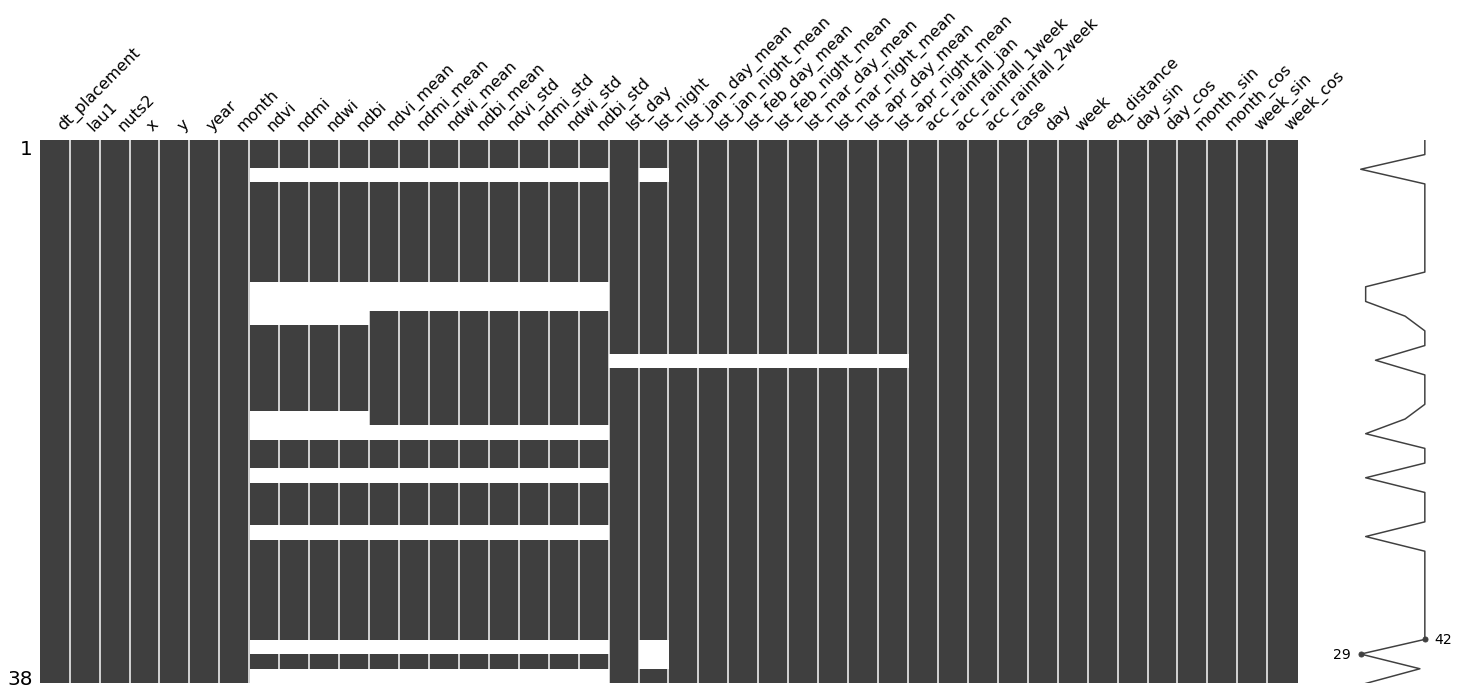

In [31]:
missingno.matrix(dataset)

In [32]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [33]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [34]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [35]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [36]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [37]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ναουσας']

Length: 1


In [38]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [39]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [40]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

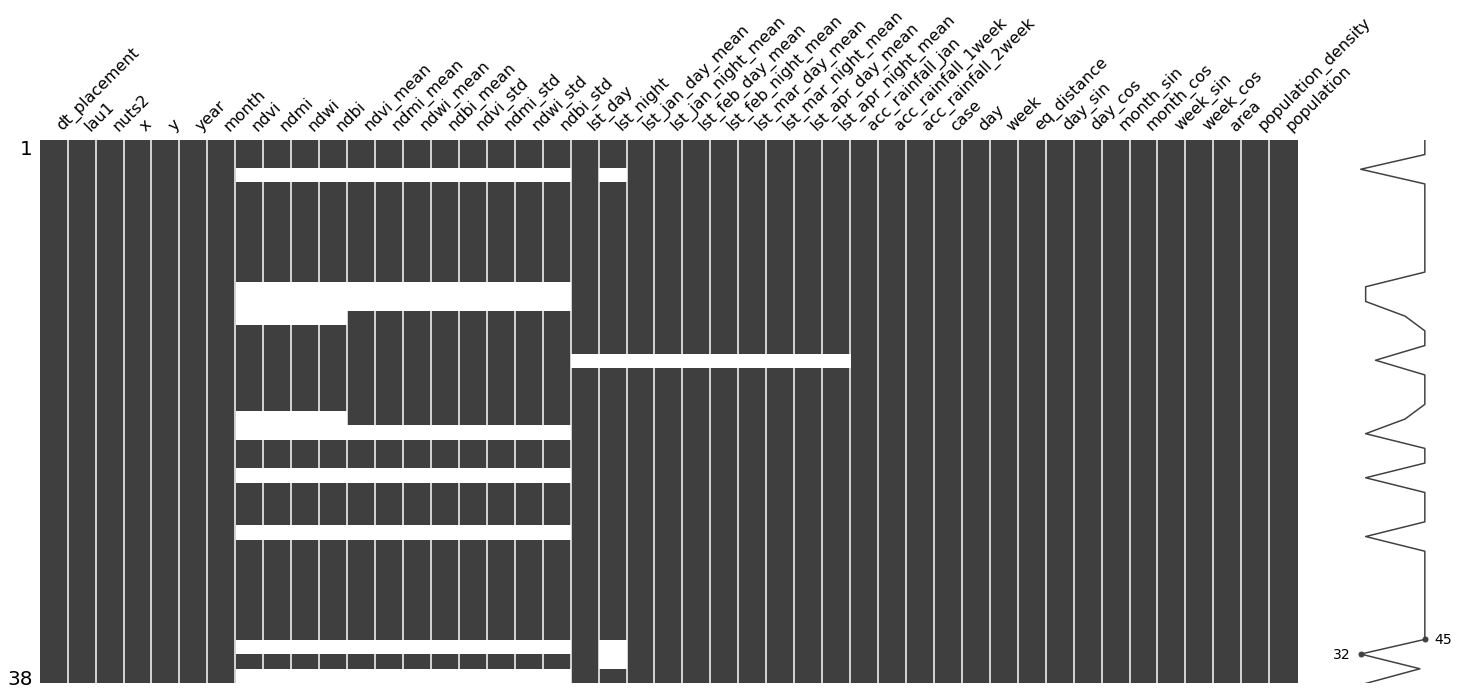

In [41]:
missingno.matrix(dataset)

In [42]:
missing = describe_dataframe(dataset)

In [43]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2023-06-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,6,0.235770,-0.062049,-0.236839,0.062049,0.214766,-0.074184,-0.225127,0.074184,0.062025,0.049040,0.047994,0.049040,15178.750000,14339.000000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,110.235503,3.816662,5.451688,0,1,22,46.44911,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,478.8,86.8,38293.0
1,2023-06-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,6,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14740.600000,14144.500000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,257.681940,3.718226,48.967830,0,1,22,46.48134,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,985.8,28.0,24924.0
2,2023-06-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15139.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,251.891959,54.540328,73.751313,0,1,22,46.65786,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,9.8,5319.1,49674.0
3,2023-06-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,6,0.505204,0.326837,-0.385542,-0.326837,0.485806,0.292957,-0.381219,-0.292957,0.053260,0.065181,0.034598,0.065181,14830.750000,14223.333333,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,106.121052,1.954789,11.972853,0,1,22,47.42581,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,411.8,22.3,7169.0
4,2023-06-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,6,0.669556,0.329771,-0.542445,-0.329771,0.658577,0.359345,-0.526910,-0.359345,0.058441,0.046232,0.051163,0.046232,14795.750000,14180.714286,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,243.895665,0.498732,18.989207,0,1,22,46.91682,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,747.0,24.5,16994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-06-01,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2023,6,0.500126,0.156601,-0.407534,-0.156601,0.491577,0.151494,-0.401857,-0.151494,0.057268,0.049846,0.035242,0.049846,14964.800000,14182.400000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,302.647467,0.765245,4.268414,0,1,22,46.65417,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,516.8,24.0,11631.0
34,2023-06-01,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2023,6,0.494128,0.098056,-0.429522,-0.098056,0.461920,0.118555,-0.392807,-0.118555,0.055241,0.065680,0.040132,0.065680,14924.000000,14221.500000,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,136.935149,3.391235,9.263252,0,1,22,47.47426,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,1103.4,20.1,18532.0
35,2023-06-01,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14921.500000,NaN,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,167.306443,4.736806,6.987233,0,1,22,46.44339,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,239.5,84.3,18080.0
36,2023-06-01,χαλκηδονος,κεντρικης μακεδονι

In [44]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-June-1st.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2023-06-01,1010
1,21.940791,40.977027,2023-06-01,62
2,22.891980,40.656030,2023-06-01,174
3,23.982527,40.915103,2023-06-01,395
4,23.691080,40.495934,2023-06-01,63
...,...,...,...,...
33,23.828106,40.110264,2023-06-01,94
34,23.388058,41.313484,2023-06-01,554
35,22.146700,40.822940,2023-06-01,177
36,22.723020,40.753567,2023-06-01,1094


In [45]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [46]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [47]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0011119492658909769


In [48]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [49]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [50]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [51]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2023-06-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,6,0.235770,-0.062049,-0.236839,0.062049,0.214766,-0.074184,-0.225127,0.074184,0.062025,0.049040,0.047994,0.049040,15178.75,14339.000000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,110.235503,3.816662,5.451688,0,1,22,46.44911,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,478.8,86.8,38293.0,1010
1,2023-06-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,6,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14740.60,14144.500000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,257.681940,3.718226,48.967830,0,1,22,46.48134,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,985.8,28.0,24924.0,62
2,2023-06-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15139.00,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,251.891959,54.540328,73.751313,0,1,22,46.65786,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,9.8,5319.1,49674.0,174
3,2023-06-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,6,0.505204,0.326837,-0.385542,-0.326837,0.485806,0.292957,-0.381219,-0.292957,0.053260,0.065181,0.034598,0.065181,14830.75,14223.333333,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,106.121052,1.954789,11.972853,0,1,22,47.42581,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,411.8,22.3,7169.0,395
4,2023-06-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,6,0.669556,0.329771,-0.542445,-0.329771,0.658577,0.359345,-0.526910,-0.359345,0.058441,0.046232,0.051163,0.046232,14795.75,14180.714286,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,243.895665,0.498732,18.989207,0,1,22,46.91682,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,747.0,24.5,16994.0,63


<AxesSubplot:>

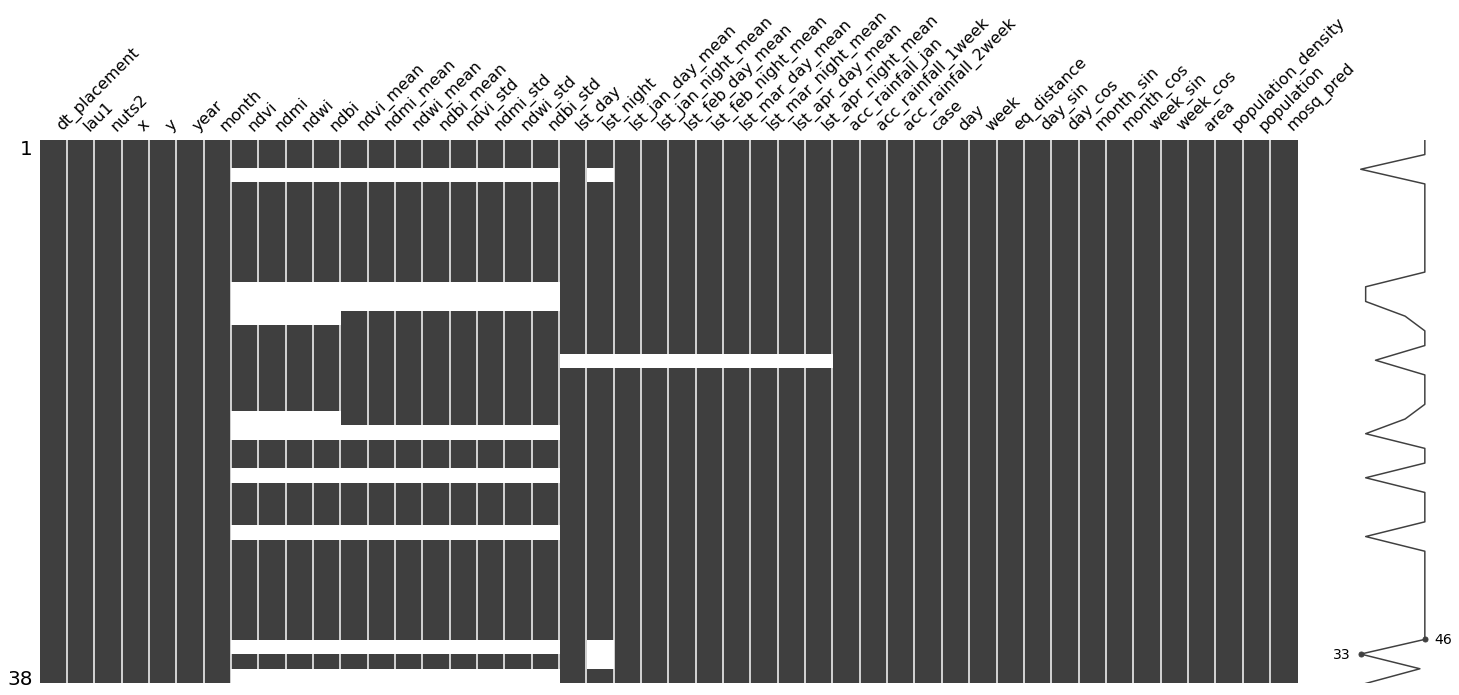

In [52]:
missingno.matrix(dataset)

In [53]:
dataset.reset_index(inplace=True, drop=True)

In [54]:
dataset = calculate_mosq_previous(dataset)

In [55]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

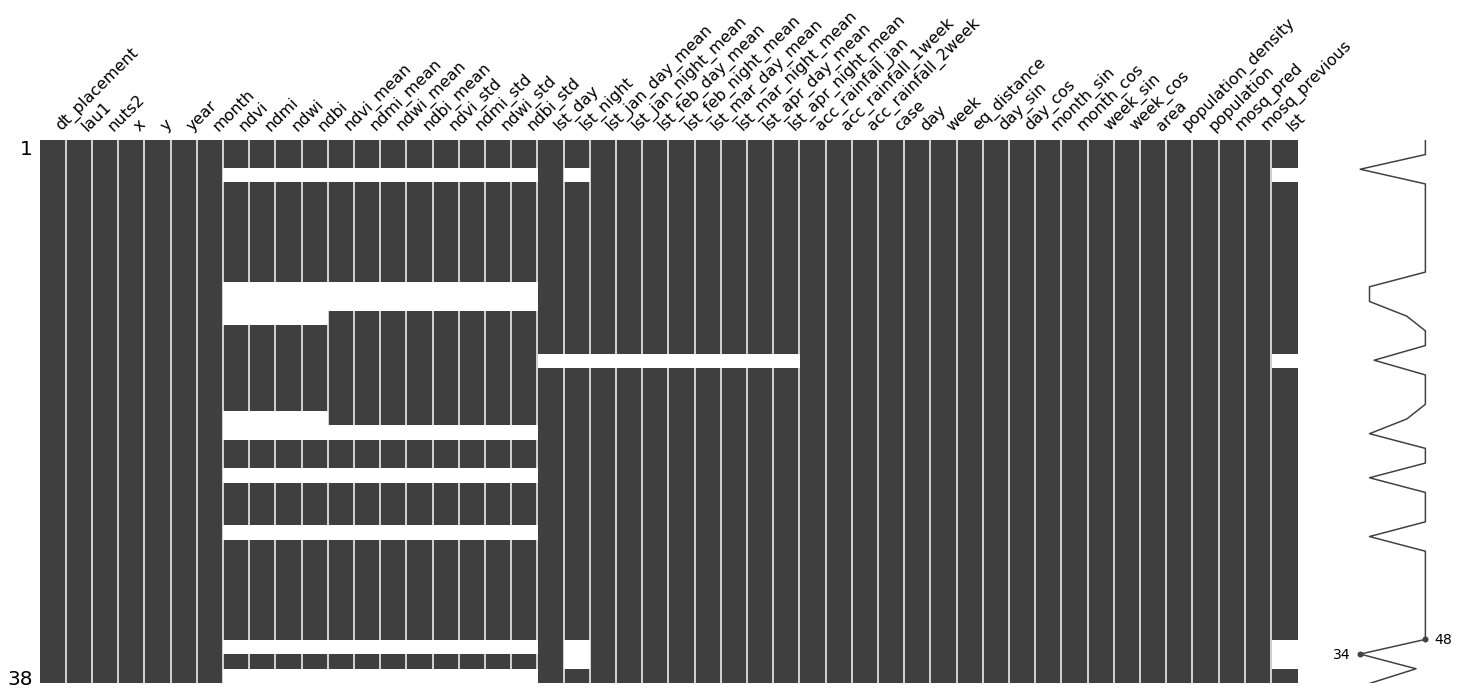

In [56]:
missingno.matrix(dataset)

In [57]:
dataset['case'].value_counts()

0    38
Name: case, dtype: int64

In [58]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [59]:
dataset = convert_multiple_cases(dataset)

In [60]:
dataset['case'].value_counts()

0    38
Name: case, dtype: int64

In [61]:
cols = dataset.columns

In [62]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [63]:
len(cols)

48

In [64]:
# check columns

In [65]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [66]:
len(final_columns)

48

In [67]:
dataset_final = dataset[final_columns].copy()

In [68]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2023-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.235770,-0.062049,-0.236839,0.062049,0.214766,-0.074184,-0.225127,0.074184,0.062025,0.049040,0.047994,0.049040,22.027500,30.425000,13.630000,11.533780,1.843800,12.127693,0.466225,22.192221,5.309037,25.273970,7.897753,3.816662,5.451688,110.235503,1010,0,0
1,21.94079,40.97703,2023-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,15.701000,21.662000,9.740000,8.005546,2.551910,7.831732,0.138556,13.334987,3.903208,14.773962,5.972576,3.718226,48.967830,257.681940,62,0,0
2,22.89198,40.65603,2023-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.630000,NaN,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,54.540328,73.751313,251.891959,174,0,0
3,23.98253,40.91510,2023-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.505204,0.326837,-0.385542,-0.326837,0.485806,0.292957,-0.381219,-0.292957,0.053260,0.065181,0.034598,0.065181,17.390833,23.465000,11.316667,10.229485,3.130833,8.615636,0.482557,15.199095,4.675023,19.470028,6.606750,1.954789,11.972853,106.121052,395,0,0
4,23.69108,40.49593,2023-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.669556,0.329771,-0.542445,-0.329771,0.658577,0.359345,-0.526910,-0.359345,0.058441,0.046232,0.051163,0.046232,16.614643,22.765000,10.464286,10.678026,3.098890,9.360022,1.950259,15.351957,4.242043,17.012319,6.938982,0.498732,18.989207,243.895665,63,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,23.82811,40.11026,2023-06-01,κεντρικης μακεδονιας,σιθωνιας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,516.8,11631.0,24.0,46.65417,0.500126,0.156601,-0.407534,-0.156601,0.491577,0.151494,-0.401857,-0.151494,0.057268,0.049846,0.035242,0.049846,18.322000,26.146000,10.498000,12.848600,5.412383,10.233594,3.269092,15.381572,5.621769,18.744510,8.323627,0.765245,4.268414,302.647467,94,0,0
34,23.38806,41.31348,2023-06-01,κεντρικης μακεδονιας,σιντικης,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,1103.4,18532.0,20.1,47.47426,0.494128,0.098056,-0.429522,-0.098056,0.461920,0.118555,-0.392807,-0.118555,0.055241,0.065680,0.040132,0.065680,18.305000,25.330000,11.280000,10.684245,2.099928,8.360350,-0.138722,15.182432,3.623271,17.447298,5.724123,3.391235,9.263252,136.935149,554,0,0
35,22.14670,40.82294,2023-06-01,κεντρικης μακεδονιας,σκυδρας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,239.5,18080.0,84.3,46.44339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.280000,NaN,11.476154,2.522000,12.264130,0.402625,18.565879,5.441556,20.967750,9.518667,4.736806,6.987233,167.306443,177,0,0
36,22.72302,40.75357,2023-06-01,κεντρικης μακεδονιας,χαλκηδονος,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,391.5,29951.0,86.0,46.66036,0

In [69]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-June-1st.csv", encoding = enc, index = False)